# Machine Learning Fundamentals

This section introduces the fundamental concepts of machine learning and deep learning that form the foundation for our magnetic field prediction approach. We explore the mathematical foundations, optimization theory, and generalization principles that enable deep learning models to learn complex relationships in electromagnetic systems.

## Learning Objectives

After completing this notebook, you will understand:

- **Neural Network Architecture**: From basic perceptrons to deep networks
- **Optimization Theory**: Gradient descent and backpropagation algorithms
- **Generalization**: Overfitting, regularization, and model selection
- **Loss Functions**: Designing objectives for regression tasks
- **Training Dynamics**: Learning rates, batch sizes, and convergence

## Historical Context and Evolution

### From Theory to Practice

Although deep learning has gained significant importance recently, its foundations date back to the 1940s:

- **1943**: McCulloch-Pitts neuron - First mathematical model of a biological neuron
- **1957**: Perceptron - Frank Rosenblatt's learning algorithm
- **1980s**: Backpropagation algorithm development
- **1990s**: LeNet-5 - First successful CNN for handwritten digit recognition
- **2012**: AlexNet - Breakthrough in ImageNet competition
- **2017+**: Transformer architectures and attention mechanisms

### Key Enabling Factors

The success of deep learning today is driven by several converging factors:

1. **Computational Power**: GPUs, TPUs, and specialized hardware
2. **Big Data**: Unprecedented availability of labeled data
3. **Algorithmic Advances**: Better architectures and optimization methods
4. **Software Ecosystem**: TensorFlow, PyTorch, and mature libraries

### Growth of Network Complexity

The number of parameters in neural networks has grown exponentially:

- **1998**: LeNet-5: ~60,000 parameters
- **2012**: AlexNet: ~60 million parameters  
- **2015**: VGG-16: ~138 million parameters
- **2018**: BERT: ~340 million parameters
- **2020+**: GPT-3: 175+ billion parameters

This growth approximately follows **Moore's Law for neural networks**, doubling every 2-3 years since the late 2000s.

## Neural Network Fundamentals

### 1. Basic Building Blocks

#### Artificial Neuron

The fundamental unit of a neural network is the **artificial neuron**, which computes:

$$y = f(\mathbf{w}^T\mathbf{x} + b)$$

where:
- $\mathbf{x}$ is the input vector
- $\mathbf{w}$ are the weights
- $b$ is the bias
- $f$ is the activation function

#### Activation Functions

Common activation functions include:

**ReLU (Rectified Linear Unit)**:
$$f(x) = \max(0, x)$$

**Sigmoid**:
$$f(x) = \frac{1}{1 + e^{-x}}$$

**Tanh**:
$$f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

### 2. Network Architectures

#### Feedforward Neural Networks

A feedforward network with $L$ layers computes:

$$\mathbf{h}^{(l)} = f^{(l)}(\mathbf{W}^{(l)}\mathbf{h}^{(l-1)} + \mathbf{b}^{(l)})$$

for $l = 1, 2, \ldots, L$, with $\mathbf{h}^{(0)} = \mathbf{x}$ (input) and $\mathbf{y} = \mathbf{h}^{(L)}$ (output).

#### Deep vs. Shallow Networks

**Universal Approximation Theorem**: A feedforward network with a single hidden layer can approximate any continuous function on a compact domain.

However, **deep networks** (multiple hidden layers) offer advantages:
- **Exponential expressivity**: Fewer parameters needed for same function complexity
- **Hierarchical feature learning**: Learn representations at multiple scales
- **Better generalization**: Implicit regularization through depth

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.patches as patches
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Machine Learning Fundamentals Framework Initialized")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Machine Learning Fundamentals Framework Initialized
PyTorch version: 2.8.0+cpu
NumPy version: 2.3.3
Matplotlib version: 3.10.7


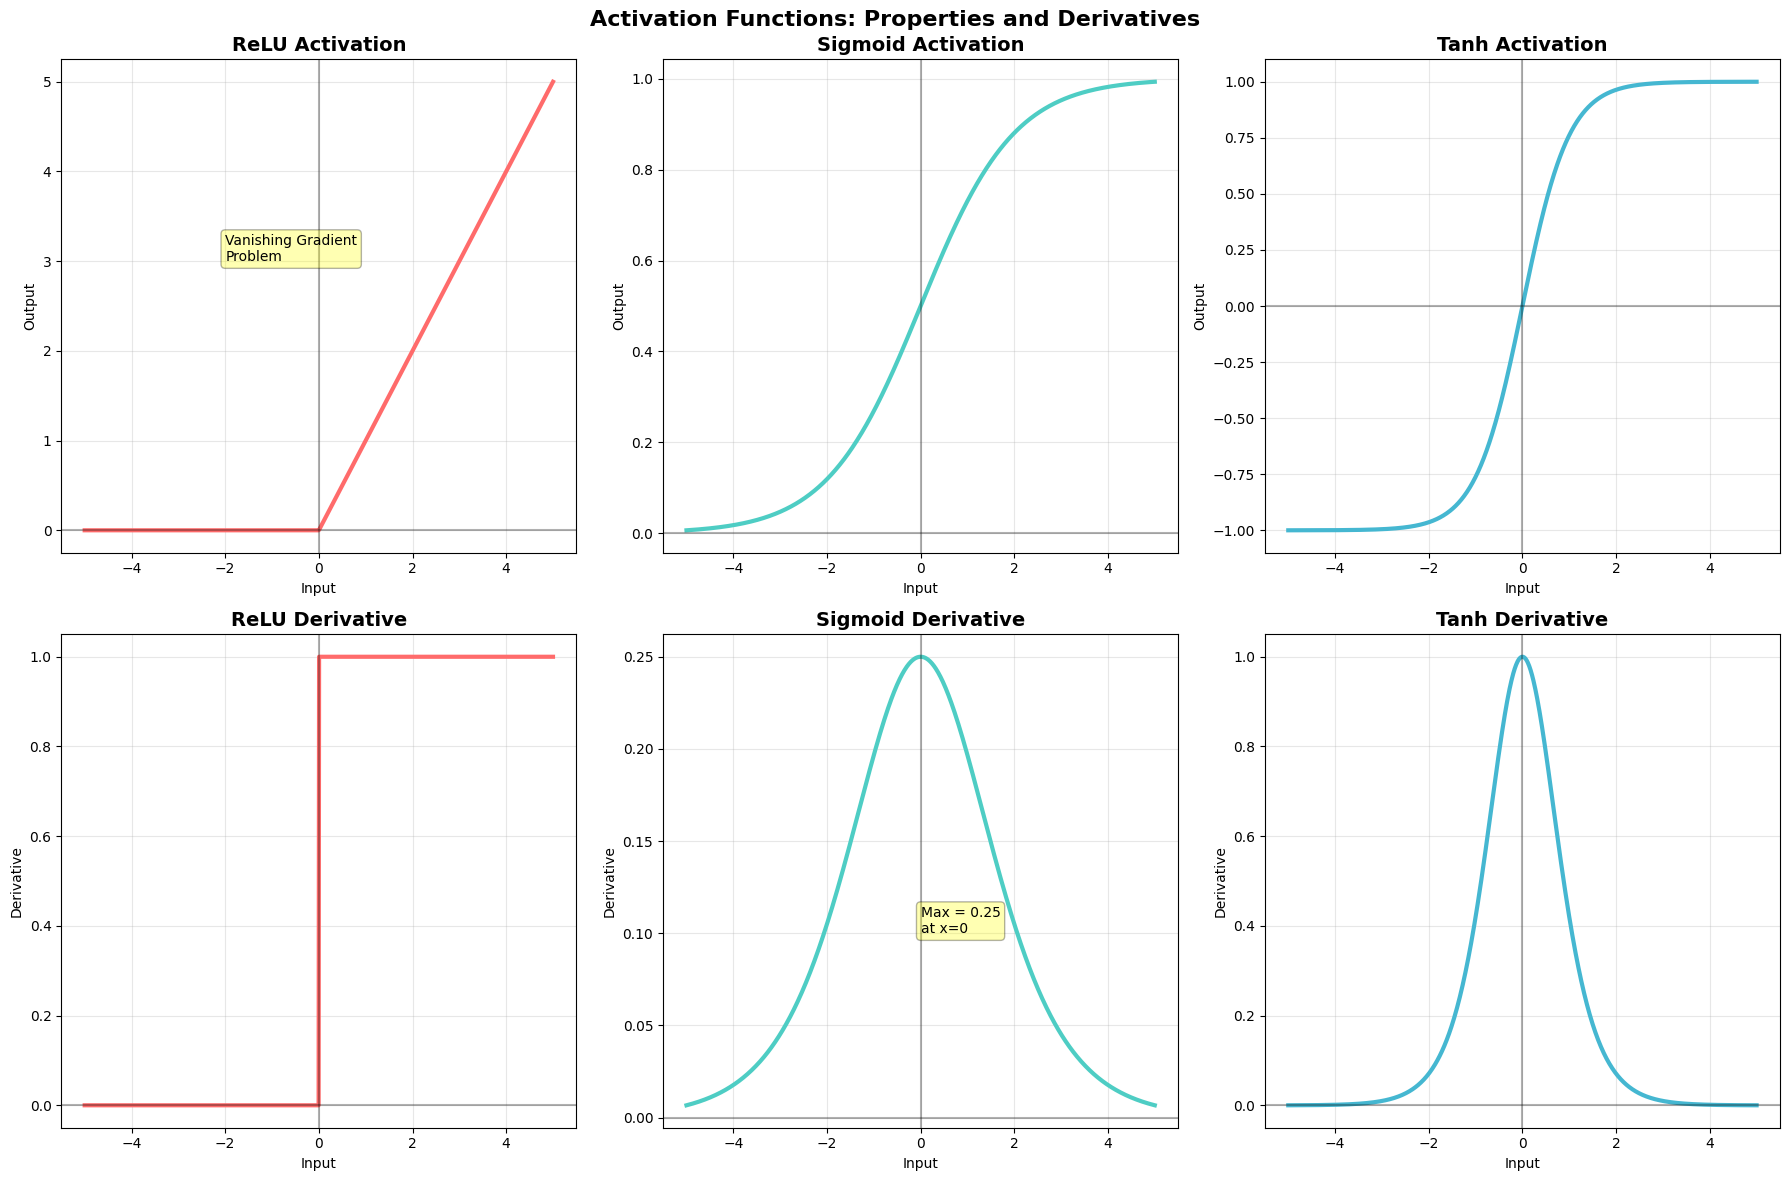

🔧 Activation Function Properties:

ReLU:
  Values at [-2, -1, 0, 1, 2]: ['0.000', '0.000', '0.000', '1.000', '2.000']
  ✓ No vanishing gradient for positive inputs
  ✓ Computationally efficient
  ⚠ Dead neuron problem for negative inputs

Sigmoid:
  Values at [-2, -1, 0, 1, 2]: ['0.119', '0.269', '0.500', '0.731', '0.881']
  ✓ Smooth gradient
  ✓ Bounded output (0, 1)
  ⚠ Vanishing gradient problem
  ⚠ Not zero-centered

Tanh:
  Values at [-2, -1, 0, 1, 2]: ['-0.964', '-0.762', '0.000', '0.762', '0.964']
  ✓ Zero-centered
  ✓ Smooth gradient
  ⚠ Vanishing gradient problem


In [2]:
# Demonstrate activation functions
def demonstrate_activation_functions():
    """Visualize different activation functions and their properties"""
    
    # Create input range
    x = np.linspace(-5, 5, 1000)
    
    # Define activation functions
    def relu(x):
        return np.maximum(0, x)
    
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    def tanh(x):
        return np.tanh(x)
    
    def leaky_relu(x, alpha=0.01):
        return np.where(x > 0, x, alpha * x)
    
    def elu(x, alpha=1.0):
        return np.where(x > 0, x, alpha * (np.exp(x) - 1))
    
    # Calculate derivatives
    def relu_grad(x):
        return np.where(x > 0, 1, 0)
    
    def sigmoid_grad(x):
        s = sigmoid(x)
        return s * (1 - s)
    
    def tanh_grad(x):
        t = tanh(x)
        return 1 - t**2
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Activation Functions: Properties and Derivatives', 
                 fontsize=16, fontweight='bold')
    
    activations = [
        (relu, relu_grad, 'ReLU', '#FF6B6B'),
        (sigmoid, sigmoid_grad, 'Sigmoid', '#4ECDC4'),
        (tanh, tanh_grad, 'Tanh', '#45B7D1')
    ]
    
    for idx, (act_func, grad_func, name, color) in enumerate(activations):
        # Plot activation function
        y = act_func(x)
        axes[0, idx].plot(x, y, linewidth=3, color=color)
        axes[0, idx].set_title(f'{name} Activation', fontweight='bold', fontsize=14)
        axes[0, idx].set_xlabel('Input')
        axes[0, idx].set_ylabel('Output')
        axes[0, idx].grid(True, alpha=0.3)
        axes[0, idx].axhline(y=0, color='k', linestyle='-', alpha=0.3)
        axes[0, idx].axvline(x=0, color='k', linestyle='-', alpha=0.3)
        
        # Plot derivative
        dy = grad_func(x)
        axes[1, idx].plot(x, dy, linewidth=3, color=color)
        axes[1, idx].set_title(f'{name} Derivative', fontweight='bold', fontsize=14)
        axes[1, idx].set_xlabel('Input')
        axes[1, idx].set_ylabel('Derivative')
        axes[1, idx].grid(True, alpha=0.3)
        axes[1, idx].axhline(y=0, color='k', linestyle='-', alpha=0.3)
        axes[1, idx].axvline(x=0, color='k', linestyle='-', alpha=0.3)
        
        # Add text annotations
        if name == 'ReLU':
            axes[0, idx].text(-2, 3, 'Vanishing Gradient\nProblem', 
                             bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.3))
        elif name == 'Sigmoid':
            axes[1, idx].text(0, 0.1, 'Max = 0.25\nat x=0', 
                             bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    # Print activation function properties
    print("🔧 Activation Function Properties:")
    print("=" * 50)
    
    test_points = [-2, -1, 0, 1, 2]
    
    for act_func, _, name, _ in activations:
        print(f"\n{name}:")
        values = [act_func(x) for x in test_points]
        print(f"  Values at {test_points}: {[f'{v:.3f}' for v in values]}")
        
        if name == 'ReLU':
            print(f"  ✓ No vanishing gradient for positive inputs")
            print(f"  ✓ Computationally efficient")
            print(f"  ⚠ Dead neuron problem for negative inputs")
        elif name == 'Sigmoid':
            print(f"  ✓ Smooth gradient")
            print(f"  ✓ Bounded output (0, 1)")
            print(f"  ⚠ Vanishing gradient problem")
            print(f"  ⚠ Not zero-centered")
        elif name == 'Tanh':
            print(f"  ✓ Zero-centered")
            print(f"  ✓ Smooth gradient")
            print(f"  ⚠ Vanishing gradient problem")

demonstrate_activation_functions()

## Optimization and Training

### 1. Loss Functions for Regression

For magnetic field prediction, we use regression loss functions:

#### Mean Squared Error (MSE)
$$\mathcal{L}_{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

#### Mean Absolute Error (MAE)
$$\mathcal{L}_{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

#### Huber Loss
$$\mathcal{L}_{Huber} = \begin{cases} \frac{1}{2}(y_i - \hat{y}_i)^2 & \text{if } |y_i - \hat{y}_i| \leq \delta \\ \delta(|y_i - \hat{y}_i| - \frac{\delta}{2}) & \text{otherwise} \end{cases}$$

### 2. Gradient Descent Variants

#### Stochastic Gradient Descent (SGD)
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \nabla \mathcal{L}(\mathbf{w}_t)$$

#### SGD with Momentum
$$\mathbf{v}_{t+1} = \beta \mathbf{v}_t + \eta \nabla \mathcal{L}(\mathbf{w}_t)$$
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \mathbf{v}_{t+1}$$

#### Adam Optimizer
$$\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1-\beta_1) \nabla \mathcal{L}(\mathbf{w}_t)$$
$$\mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1-\beta_2) \nabla \mathcal{L}(\mathbf{w}_t)^2$$
$$\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1-\beta_1^t}, \quad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1-\beta_2^t}$$
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon}$$

SGD             Epoch    0: Loss = 0.889543
SGD             Epoch  100: Loss = 0.233926
SGD             Epoch  200: Loss = 0.119087


SGD             Epoch  300: Loss = 0.059930
SGD             Epoch  400: Loss = 0.035706
SGD             Epoch  500: Loss = 0.025151


SGD             Epoch  600: Loss = 0.019594
SGD             Epoch  700: Loss = 0.016249
SGD             Epoch  800: Loss = 0.014298


SGD             Epoch  900: Loss = 0.013112
SGD + Momentum  Epoch    0: Loss = 0.641165
SGD + Momentum  Epoch  100: Loss = 0.012781


SGD + Momentum  Epoch  200: Loss = 0.010909
SGD + Momentum  Epoch  300: Loss = 0.010594
SGD + Momentum  Epoch  400: Loss = 0.010484


...

RMSprop         Epoch    0: Loss = 0.743842
RMSprop         Epoch  100: Loss = 0.029465


RMSprop         Epoch  200: Loss = 0.014000
RMSprop         Epoch  300: Loss = 0.018708


RMSprop         Epoch  400: Loss = 0.020942
RMSprop         Epoch  500: Loss = 0.018928


RMSprop         Epoch  600: Loss = 0.019452
RMSprop         Epoch  700: Loss = 0.019103


RMSprop         Epoch  800: Loss = 0.018691
RMSprop         Epoch  900: Loss = 0.017708


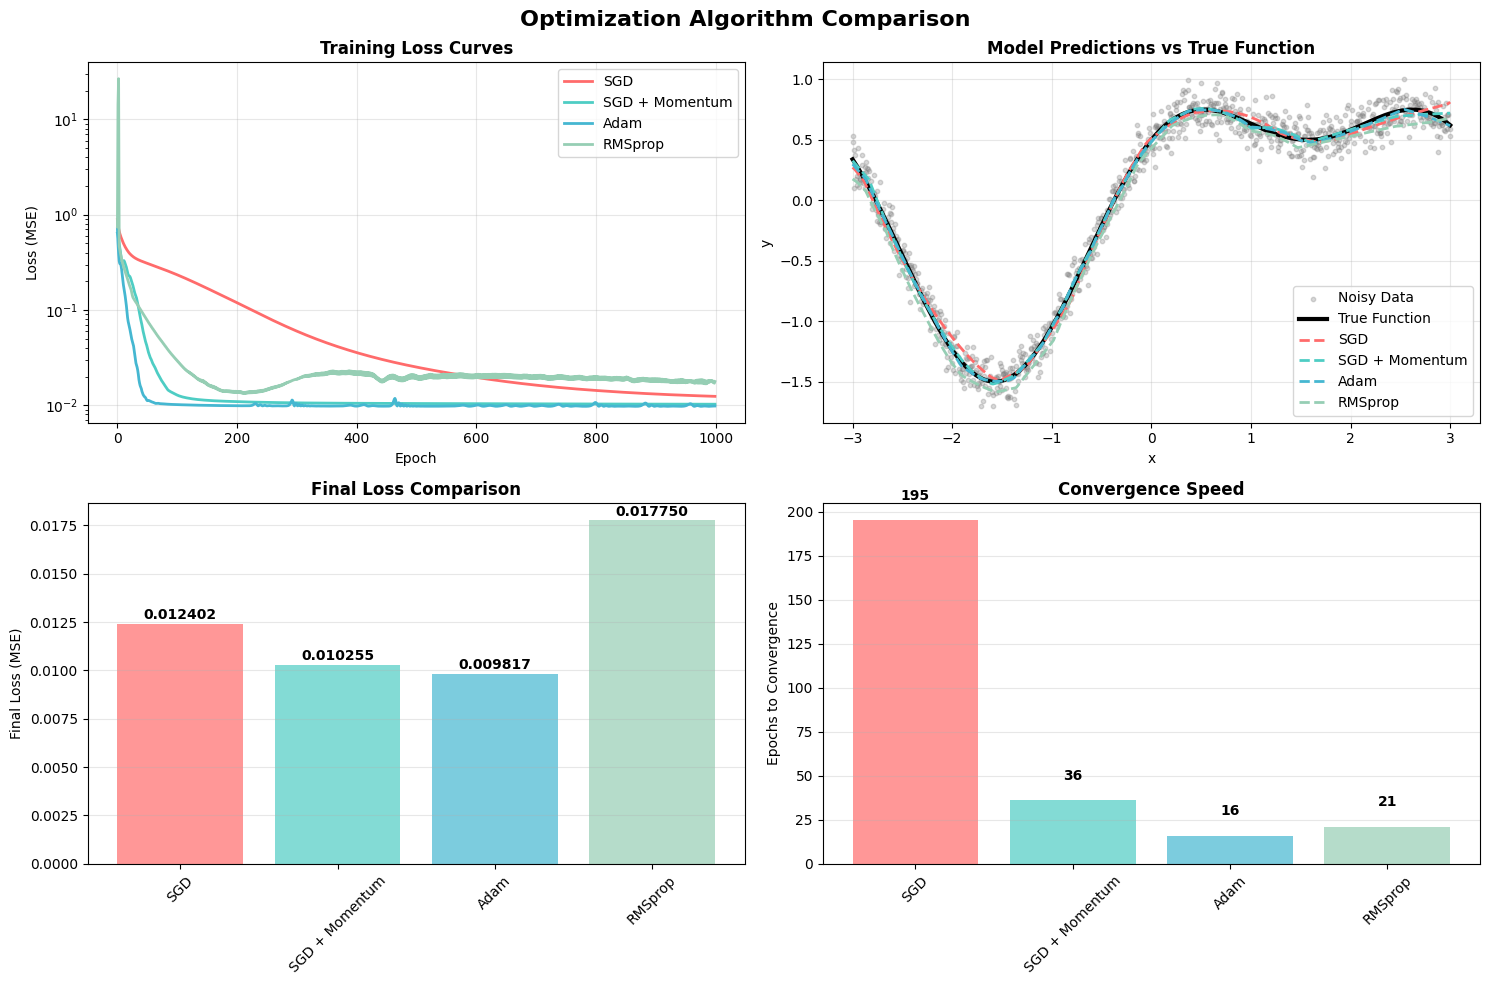


📊 Optimization Algorithm Summary:
SGD            : Final Loss = 0.012402, R² = 0.9964
SGD + Momentum : Final Loss = 0.010255, R² = 0.9993
Adam           : Final Loss = 0.009817, R² = 0.9996
RMSprop        : Final Loss = 0.017750, R² = 0.9895


In [3]:
# Demonstrate optimization algorithms
class SimpleNeuralNetwork(nn.Module):
    """Simple neural network for optimization demonstration"""
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=1):
        super(SimpleNeuralNetwork, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.layers(x)

def demonstrate_optimization_algorithms():
    """Compare different optimization algorithms on a simple regression task"""
    
    # Generate synthetic data
    np.random.seed(42)
    torch.manual_seed(42)
    
    # Create a non-linear function: y = sin(x) + 0.5*cos(2*x) + noise
    n_samples = 1000
    x = torch.linspace(-3, 3, n_samples).unsqueeze(1)
    y_true = torch.sin(x) + 0.5 * torch.cos(2*x)
    y = y_true + 0.1 * torch.randn_like(x)
    
    # Create 2D input (x, x^2) for more interesting problem
    X = torch.cat([x, x**2], dim=1)
    
    # Test different optimizers
    optimizers = {
        'SGD': lambda model: torch.optim.SGD(model.parameters(), lr=0.01),
        'SGD + Momentum': lambda model: torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9),
        'Adam': lambda model: torch.optim.Adam(model.parameters(), lr=0.01),
        'RMSprop': lambda model: torch.optim.RMSprop(model.parameters(), lr=0.01)
    }
    
    results = {}
    n_epochs = 1000
    
    # Train with each optimizer
    for opt_name, opt_func in optimizers.items():
        # Create fresh model
        model = SimpleNeuralNetwork(input_dim=2, hidden_dim=32, output_dim=1)
        optimizer = opt_func(model)
        criterion = nn.MSELoss()
        
        losses = []
        
        for epoch in range(n_epochs):
            # Forward pass
            y_pred = model(X)
            loss = criterion(y_pred, y)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            losses.append(loss.item())
            
            if epoch % 100 == 0:
                print(f"{opt_name:15s} Epoch {epoch:4d}: Loss = {loss.item():.6f}")
        
        results[opt_name] = {
            'model': model,
            'losses': losses,
            'final_loss': losses[-1]
        }
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Optimization Algorithm Comparison', fontsize=16, fontweight='bold')
    
    # Plot 1: Training curves
    axes[0, 0].set_title('Training Loss Curves', fontweight='bold')
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i, (opt_name, result) in enumerate(results.items()):
        axes[0, 0].plot(result['losses'], label=opt_name, color=colors[i], linewidth=2)
    
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss (MSE)')
    axes[0, 0].set_yscale('log')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Final predictions
    axes[0, 1].set_title('Model Predictions vs True Function', fontweight='bold')
    axes[0, 1].scatter(x.numpy(), y.numpy(), alpha=0.3, s=10, color='gray', label='Noisy Data')
    axes[0, 1].plot(x.numpy(), y_true.numpy(), 'k-', linewidth=3, label='True Function')
    
    for i, (opt_name, result) in enumerate(results.items()):
        with torch.no_grad():
            y_pred = result['model'](X)
        axes[0, 1].plot(x.numpy(), y_pred.numpy(), '--', linewidth=2, 
                       color=colors[i], label=opt_name)
    
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('y')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Final loss comparison
    axes[1, 0].set_title('Final Loss Comparison', fontweight='bold')
    opt_names = list(results.keys())
    final_losses = [results[name]['final_loss'] for name in opt_names]
    bars = axes[1, 0].bar(opt_names, final_losses, color=colors[:len(opt_names)], alpha=0.7)
    axes[1, 0].set_ylabel('Final Loss (MSE)')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, loss in zip(bars, final_losses):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                       f'{loss:.6f}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 4: Convergence speed (epochs to reach 90% of final performance)
    axes[1, 1].set_title('Convergence Speed', fontweight='bold')
    convergence_epochs = []
    
    for opt_name, result in results.items():
        final_loss = result['final_loss']
        target_loss = final_loss * 10  # 10x final loss as target
        
        for epoch, loss in enumerate(result['losses']):
            if loss <= target_loss:
                convergence_epochs.append(epoch)
                break
        else:
            convergence_epochs.append(n_epochs)
    
    bars = axes[1, 1].bar(opt_names, convergence_epochs, color=colors[:len(opt_names)], alpha=0.7)
    axes[1, 1].set_ylabel('Epochs to Convergence')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, epoch in zip(bars, convergence_epochs):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                       f'{epoch}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n📊 Optimization Algorithm Summary:")
    print("=" * 50)
    for opt_name, result in results.items():
        final_loss = result['final_loss']
        r2 = r2_score(y_true.numpy(), result['model'](X).detach().numpy())
        print(f"{opt_name:15s}: Final Loss = {final_loss:.6f}, R² = {r2:.4f}")

demonstrate_optimization_algorithms()

## Generalization and Regularization

### 1. Bias-Variance Tradeoff

The expected prediction error can be decomposed as:

$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

- **Bias**: Error from erroneous assumptions in the learning algorithm
- **Variance**: Error from sensitivity to small fluctuations in training set
- **Irreducible Error**: Noise inherent in the problem

### 2. Regularization Techniques

#### L2 Regularization (Weight Decay)
$$\mathcal{L}_{reg} = \mathcal{L}_{data} + \lambda \sum_{i} w_i^2$$

#### L1 Regularization
$$\mathcal{L}_{reg} = \mathcal{L}_{data} + \lambda \sum_{i} |w_i|$$

#### Dropout
During training, randomly set a fraction $p$ of neurons to zero:
$$\tilde{h}_i = \begin{cases} 0 & \text{with probability } p \\ \frac{h_i}{1-p} & \text{otherwise} \end{cases}$$

#### Early Stopping
Monitor validation loss and stop training when it starts increasing.

### 3. Model Selection and Validation

#### K-Fold Cross-Validation
Split data into K folds, train on K-1 folds and validate on the remaining fold. Repeat K times.

#### Hyperparameter Optimization
- **Grid Search**: Exhaustive search over predefined parameter grid
- **Random Search**: Random sampling from parameter distributions
- **Bayesian Optimization**: Sequential model-based optimization

## Summary

This notebook provides the fundamental machine learning concepts necessary for understanding and implementing deep learning models for magnetic field prediction:

### ✅ **Key Concepts Covered**

1. **Neural Network Architecture**: From basic neurons to deep networks
2. **Activation Functions**: Properties and practical considerations
3. **Optimization Algorithms**: SGD, momentum, and adaptive methods
4. **Loss Functions**: Regression objectives for field prediction
5. **Regularization**: Techniques to prevent overfitting
6. **Training Dynamics**: Understanding convergence and model selection

### 🎯 **Practical Applications**

These fundamentals directly apply to magnetic field prediction:

- **Network Design**: Choosing appropriate architectures for field regression
- **Optimization**: Selecting optimizers for stable training of physics-based models
- **Regularization**: Ensuring models generalize to new electromagnetic geometries
- **Validation**: Robust evaluation of model performance on unseen designs

### 🚀 **Next Steps**

With this foundation, we can now explore:
- **Convolutional Neural Networks** for spatial field prediction
- **Uncertainty Quantification** for reliable predictions
- **Physics-Informed Neural Networks** for incorporating domain knowledge

These concepts form the theoretical and practical foundation for developing sophisticated deep learning models that can accurately predict magnetic fields in electromagnetic devices.